# Object segmentation network

## Table of Contents

### Import libraries


In [1]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import numpy as np

from torchvision import transforms
from torch.utils.data import DataLoader

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch
from torch.utils.data import DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import torchvision.transforms as T
import torch.optim as optim
import torchvision

from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.patches as patches


<a id="Initialize-the-data-loader"></a>
### Data loader implementation

In [2]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths, self.annotation_paths = self.collect_paths(root_dir)

    def collect_paths(self, root_dir):
        image_paths = []
        annotation_paths = []

        annotation_root = os.path.join(root_dir, "Annotations")
        image_root = os.path.join(root_dir, "Images")

        for subdir in os.listdir(annotation_root):
            annotation_subfolder = os.path.join(annotation_root, subdir)
            image_subfolder = os.path.join(image_root, subdir)

            if os.path.isdir(annotation_subfolder) and os.path.isdir(image_subfolder):
                for filename in os.listdir(annotation_subfolder):
                    if filename.endswith(".txt"):
                        annotation_path = os.path.join(annotation_subfolder, filename)
                        image_filename = os.path.splitext(filename)[0] + ".jpg"
                        image_path = os.path.join(image_subfolder, image_filename)
                        if os.path.exists(image_path):
                            annotation_paths.append(annotation_path)
                            image_paths.append(image_path)

        return image_paths, annotation_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        annotation_path = self.annotation_paths[idx]

        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)

        # Load and parse annotation (you'll need to implement this part based on the content of your annotation file)
        boxes = self.parse_annotation(annotation_path)
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        num_objs = len(boxes) 
        
        if num_objs == 0:
            # area = torch.tensor([ 0.0 ])
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.ones((len(boxes),), dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] -     boxes[:, 0])
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
            
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx]),
            'area': area,
            'iscrowd': iscrowd
        }
        
        return image, target

    def parse_annotation(self, annotation_path):
        with open(annotation_path, 'r') as file:
            lines = file.readlines()

        num_objects = int(lines[0].strip())
        bounding_boxes = []

        for i in range(1, num_objects + 1):
            values = list(map(int, lines[i].strip().split()))
            if len(values) == 4:
                bounding_boxes.append(values)

        return bounding_boxes

### Initialize the data loader

In [3]:
import os
import platform
# Define your data transformation (e.g., resizing, normalization, etc.)
transform = transforms.Compose([
    transforms.Resize((560, 480)),
    transforms.ToTensor(),
])

root_dir_mac = '/Volumes/SSD_6Gbps/dataset1/TrainValid/TrainValid'
root_dir_windows = './data/TrainValid/TrainValid'

system_name = platform.system()
if system_name == "Windows":
    print("Windows")
    # Create an instance of the custom dataset
    dataset = CustomDataset(root_dir=root_dir_windows, transform=transform)
elif system_name == "Linux":
    print("Linux")
    dataset = CustomDataset(root_dir=root_dir_windows, transform=transform)
elif system_name == "Darwin":
    print("macOS")
    dataset = CustomDataset(root_dir=root_dir_mac, transform=transform)

# Create a DataLoader to iterate through the dataset
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

macOS


### Test the data loader
(re-run this cell to see different examples)

tensor([[205.,  22., 311., 146.]])


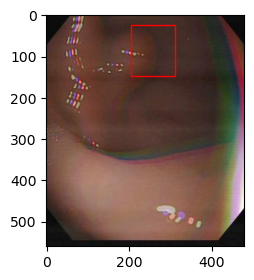

tensor([[236., 102., 438., 366.]])


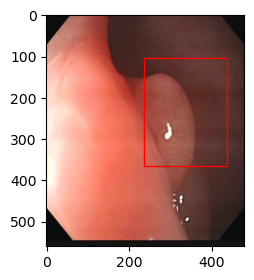

tensor([[394., 323., 453., 389.]])


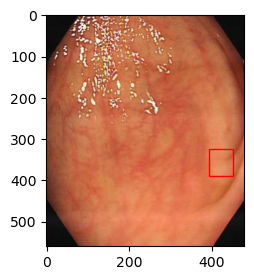

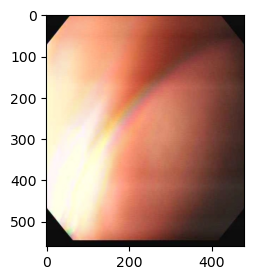

tensor([[222., 262., 377., 413.]])


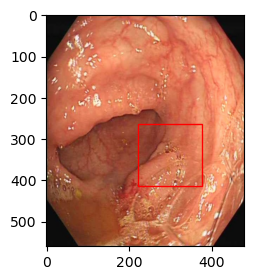

In [4]:
max_images_to_display = 5  # Set the maximum number of images to display
image_counter = 0    # Initialize a counter

# Set the desired figure size
fig_width, fig_height = 4, 3  # Adjust these values to your preference

# Test by iterating through the dataset
for image, target in dataloader:
    # Convert the PyTorch tensor to a NumPy array for visualization
    image = image.squeeze(0).permute(1, 2, 0).numpy()

    # Create a figure and axis
    fig, ax = plt.subplots(1, figsize=(fig_width, fig_height))
    ax.imshow(image)
    
    bounding_boxes = target['boxes']
    # Iterate through bounding boxes and draw them on the image
    if bounding_boxes.numel() > 0:
        for box in bounding_boxes:
            print(box)
            box = box.squeeze(0) # flatten the tensor to avoid unpacking error
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

    # Show the image with bounding boxes
    plt.show()
    
    # Increment the image counter
    image_counter += 1

    if image_counter >= max_images_to_display:
        break  # Exit the loop after displaying the desired number of images

### Select the device to train the model on 
(GPU by default if available)

In [17]:
import torch
import platform

# Enable MPS fallback
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Check if CUDA is available, which it will be on most Windows/Linux machines with NVIDIA GPUs
if torch.cuda.is_available():
    device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


### Define the data collate function for the DataLoader
(which combines multiple images into a batch)

In [18]:
def collate_fn(batch):
    images, targets = zip(*batch)  # Transpose the batch (turn list of pairs into pair of lists)

    images = list(image for image in images)
    targets = list(target for target in targets)

    images = torch.stack(images, dim=0)  # Stack images to create a 4D tensor

    # In case of targets, we don't stack or pad because Faster R-CNN can handle varying-size targets
    return images, targets

### Define the model

In [19]:
# Split the dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, collate_fn=collate_fn)

# Define the model
model = fasterrcnn_resnet50_fpn(weights=True)

# Modify the model for your specific dataset: Change the number of classes
# num_classes = 1 # 1 class (Polyp) + background
num_classes = 2  # 1 class (polyp) + 1 background

# Get the number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features
# Replace the pre-trained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Define the optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

model = model.to(device)
print("Classes in the model's classifier:", model.roi_heads.box_predictor.cls_score.out_features)

Classes in the model's classifier: 2


### Test the training of the model to see if it works 

In [20]:

# For Training
images, targets = next(iter(train_loader))
images = [image.to(device) for image in images]
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]  # Move targets to the device

output = model(images, targets)  # Returns losses and detections
print(output)

{'loss_classifier': tensor(0.5006, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0258, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0173, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0026, grad_fn=<DivBackward0>)}


{'boxes': tensor([[3.0656e+02, 2.2182e+02, 3.1606e+02, 2.3373e+02],
        [3.4470e+02, 2.0807e+02, 3.5410e+02, 2.1539e+02],
        [3.0568e+02, 2.2312e+02, 3.1421e+02, 2.3866e+02],
        [1.8833e+01, 1.6196e+01, 3.0642e+02, 1.2934e+02],
        [3.9643e+01, 2.9228e+02, 4.9420e+01, 3.0774e+02],
        [7.7438e+01, 2.1658e+01, 2.5052e+02, 7.6774e+01],
        [3.4828e+02, 2.0706e+02, 3.5649e+02, 2.1665e+02],
        [5.0377e+01, 6.6823e+00, 2.1053e+02, 1.5637e+02],
        [5.8605e+01, 3.5608e+00, 2.0090e+02, 5.6917e+01],
        [3.4504e+02, 2.0969e+02, 3.5467e+02, 2.1877e+02],
        [3.0878e+02, 2.2377e+02, 3.1934e+02, 2.4075e+02],
        [3.8237e+02, 2.0842e+02, 3.9089e+02, 2.1933e+02],
        [3.8182e+02, 2.1329e+02, 3.9069e+02, 2.2333e+02],
        [3.7281e+02, 2.0574e+02, 3.9008e+02, 2.2257e+02],
        [3.9697e+02, 4.5366e+02, 4.8000e+02, 5.4309e+02],
        [3.1461e+02, 2.2489e+02, 3.2321e+02, 2.3593e+02],
        [3.5161e+02, 2.0851e+02, 3.5745e+02, 2.1630e+02],
    

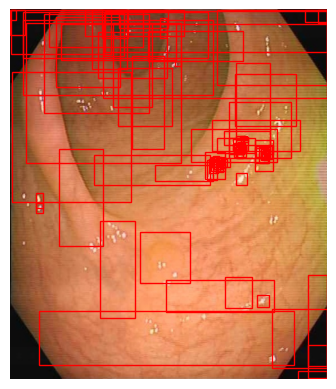

In [21]:
# For inference
model.eval()

# Get a batch of images from the DataLoader
images, targets = next(iter(train_loader))

# Select the first image from the batch for inference
# Assuming your DataLoader returns a batch of images and targets
image_to_infer = images[0].unsqueeze(0).to(device)  # Add batch dimension and move to the device

# Disable gradient computation since we're only doing inference
with torch.no_grad():
    # Perform inference
    predictions = model(image_to_infer)  # Returns predictions

    # Print out the predictions for the first image
    print(predictions[0])
    
# Process the first image and its prediction
image = image_to_infer[0].cpu().numpy()  # Move the tensor to cpu and convert to numpy
image = np.transpose(image, (1, 2, 0))  # Transpose from CxHxW to HxWxC for matplotlib

# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off the axis

# Add the predicted bounding boxes
for box in predictions[0]['boxes']:
    xmin, ymin, xmax, ymax = box.cpu().numpy()
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=1, edgecolor='r', facecolor='none')
    plt.gca().add_patch(rect)

### Train the model

In [22]:
def validate(model, val_loader, device):
    model.eval()  # Set the model to evaluation mode
    val_loss = 0
    with torch.no_grad():  # Disable gradient calculation
        for images, targets in val_loader:
            images = list(img.to(device) for img in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss += losses.item()

    return val_loss / len(val_loader)

In [23]:
# Train the model
num_epochs = 2
epoch_losses = []  # List to store epoch loss
batch_losses = []  # List to store losses for each batch

best_val_loss = float('inf')  # Initialize best validation loss

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0  # Keep track of the total loss for this epoch
    for images, targets in train_loader:
        # Move images and targets to device
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in target.items()} for target in targets]
       
        # Debugging code to check the device of the inputs 
        # print(f"Device of model parameters: {[p.device for p in model.parameters()]}")
        # print(f"Device of images: {images[0].device}")
        # print(f"Device of targets: {targets[0]['boxes'].device}")

        loss_dict = model(images, targets)
        losses = sum(loss.to(device) for loss in loss_dict.values())
        
        epoch_loss += losses.item()  # Add the batch loss to the total epoch loss

        # Record the loss for the current batch
        batch_loss = losses.item()
        batch_losses.append(batch_loss)
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
    # After training for an epoch, validate
    val_loss = validate(model, val_loader, device)
    
    # Check if this is the best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pth')

    # Print out the information
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')
    # Append the epoch loss to the list
    epoch_losses.append(epoch_loss)
    # Update the learning rate
    lr_scheduler.step()
    # Print learning rate for each parameter group
    for param_group in optimizer.param_groups:
        print(f'Learning Rate: {param_group["lr"]:.6f}')

KeyboardInterrupt: 

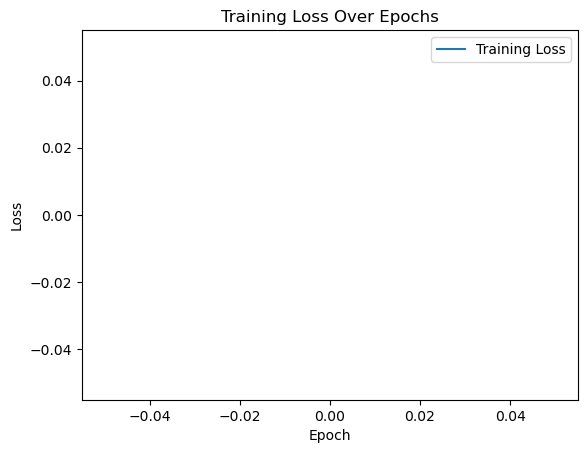

In [24]:
# After training, you can plot the epoch losses
plt.plot(epoch_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

### Saving the model

In [ ]:
# Generate a timestamp or unique identifier
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define a directory to save the models
save_dir = "./saved_models/"

# Create the parent directory if it doesn't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save the generator model and optimizer state with a unique filename
generator_checkpoint_file = f"{save_dir}generator_checkpoint_{timestamp}.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': model.state_dict()
}, generator_checkpoint_file)

# Define filenames with timestamps
epoch_losses_filename =  os.path.join(save_dir, f"epoch_losses_{timestamp}.txt")
batch_losses_filename =  os.path.join(save_dir, f"batch_losses_{timestamp}.txt")
 
# Save to a file with a timestamp
with open(epoch_losses_filename, 'w') as file:
    for loss in epoch_losses:
        file.write(f"{loss}\n")
        
with open(batch_losses_filename, 'w') as file:
    for loss in batch_losses:
        file.write(f"{loss}\n")

### Loading the model

In [ ]:
# Provide the timestamp you want to load
specified_timestamp = "20231022200319"  # Replace with the desired timestamp

# Load the generator model and optimizer state
checkpoint = torch.load(f'./saved_models/generator_checkpoint_{specified_timestamp}.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.load_state_dict(checkpoint['optimizer_state_dict'])

# Define the filenames based on the specified timestamp
specified_epoch_losses_filename = f"./saved_models/epoch_losses_{specified_timestamp}.txt"
specified_batch_losses_filename = f"./saved_models/batch_losses_{specified_timestamp}.txt"

# Define lists to store the loaded losses
loaded_epoch_losses = []
loaded_batch_losses = []

# Load G_losses from the file with the specified timestamp
with open(specified_batch_losses_filename, 'r') as file:
    for line in file:
        loaded_batch_losses.append(float(line.strip()))

# Load D_losses from the file with the specified timestamp
with open(specified_epoch_losses_filename, 'r') as file:
    for line in file:
        loaded_epoch_losses.append(float(line.strip()))

epoch_losses = loaded_epoch_losses
batch_losses = loaded_batch_losses

Evaluate model

In [25]:
from torchvision.ops import box_iou

def evaluate(model, val_loader, device, iou_threshold=0.5):
    model.eval()
    ious = []

    with torch.no_grad():
        for images, targets in val_loader:
            images = list(img.to(device) for img in images)
            outputs = model(images)

            for target, output in zip(targets, outputs):
                gt_boxes = target['boxes'].to(device)
                pred_boxes = output['boxes'].to(device)
                scores = output['scores'].to(device)

                # Compute IoU for the predicted and ground truth boxes
                iou_matrix = box_iou(pred_boxes, gt_boxes)

                # Here, we're considering a prediction to be correct if the IoU is greater than the threshold
                # This part assumes a one-to-one matching which can be improved by using a matching strategy
                correct_preds = iou_matrix > iou_threshold

                # Now extract the IoUs for the correct predictions
                # This will give us the IoUs where the prediction was correct
                matched_ious = iou_matrix[correct_preds]

                ious.extend(matched_ious.cpu().tolist())

    # Calculate metrics based on the IoUs
    true_positives = len(ious)
    false_positives = len(outputs) - true_positives
    false_negatives = len(targets) - true_positives

    # Precision, recall, and F1 score calculations
    precision = true_positives / (true_positives + false_positives) if true_positives + false_positives > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if true_positives + false_negatives > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'ious': ious  # List of IoU for correctly predicted boxes
    }

# Usage:
metrics = evaluate(model, val_loader, device)
print(f"Precision: {metrics['precision']}")
print(f"Recall: {metrics['recall']}")
print(f"F1 Score: {metrics['f1']}")
print(f"Average IoU: {sum(metrics['ious']) / len(metrics['ious']) if metrics['ious'] else 0}")


KeyboardInterrupt: 

## Data augmentation

### Data augmentation network

In [ ]:
# # Importar las bibliotecas necesarias
# import torch
# from torch import nn
# from torch.optim import Adam
# from torchvision import transforms
# from torchvision.datasets import ImageFolder
# from torch.utils.data import DataLoader
# from cycle_gan_model import Generator, Discriminator  # Suponiendo que tienes implementaciones de Generator y Discriminator
# 
# # Definir transformaciones para las imágenes
# transform = transforms.Compose([
#     transforms.Resize((256, 256)),  # Cambiar al tamaño deseado
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
# ])
# 
# # Cargar los datasets
# # Supongamos que tienes dos carpetas: '/path/to/masks' para máscaras y '/path/to/real_images' para imágenes reales
# dataset_masks = ImageFolder('/path/to/masks', transform=transform)
# dataset_real_images = ImageFolder('/path/to/real_images', transform=transform)
# 
# # Crear DataLoaders para los datasets
# loader_masks = DataLoader(dataset_masks, batch_size=1, shuffle=True)
# loader_real_images = DataLoader(dataset_real_images, batch_size=1, shuffle=True)
# 
# # Inicializar los modelos GAN
# G_mask_to_image = Generator()  # Generador que convierte máscaras en imágenes
# G_image_to_mask = Generator()  # Generador que convierte imágenes en máscaras
# D_image = Discriminator()  # Discriminador para imágenes
# D_mask = Discriminator()  # Discriminador para máscaras
# 
# # Mover modelos al dispositivo adecuado (CPU o GPU)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# G_mask_to_image.to(device)
# G_image_to_mask.to(device)
# D_image.to(device)
# D_mask.to(device)
# 
# # Definir los optimizadores para los generadores y discriminadores
# optimizer_G = Adam(list(G_mask_to_image.parameters()) + list(G_image_to_mask.parameters()), lr=0.0002, betas=(0.5, 0.999))
# optimizer_D_image = Adam(D_image.parameters(), lr=0.0002, betas=(0.5, 0.999))
# optimizer_D_mask = Adam(D_mask.parameters(), lr=0.0002, betas=(0.5, 0.999))
# 
# # Definir la función de pérdida (adversarial loss)
# criterion_GAN = nn.MSELoss()
# criterion_cycle = nn.L1Loss()  # Para la consistencia cíclica
# criterion_identity = nn.L1Loss()  # Para la pérdida de identidad (opcional)
# 
# # Bucle de entrenamiento
# for epoch in range(num_epochs):
#     for mask, real_image in zip(loader_masks, loader_real_images):
# 
#         # Preparar los inputs
#         real_image = real_image.to(device)
#         mask = mask.to(device)
# 
#         # Generar una imagen falsa a partir de la máscara
#         fake_image = G_mask_to_image(mask)
# 
#         # Entrenar los discriminadores (D_image y D_mask)
#         # ...
# 
#         # Calcular la pérdida para los generadores (G_mask_to_image y G_image_to_mask)
#         # ...
# 
#         # Retropropagación y optimización para los generadores
#         # ...
# 
#         # Retropropagación y optimización para los discriminadores
#         # ...
# 
# # Guardar los modelos entrenados
# torch.save(G_mask_to_image.state_dict(), 'G_mask_to_image.pth')
# torch.save(G_image_to_mask.state_dict(), 'G_image_to_mask.pth')
# torch.save(D_image.state_dict(), 'D_image.pth')
# torch.save(D_mask.state_dict(), 'D_mask.pth')
# 
# # Generar imágenes para evaluación o más entrenamiento
# G_mask_to_image.eval()
# with torch.no_grad():
#     for mask in loader_masks:
#         mask = mask.to(device)
#         synthetic_image = G_mask_to_image(mask)
#         # Guardar o utilizar synthetic_image
